# Pension model

In [1]:
import sys
import os

project_root = os.path.abspath("../")  # one level up from notebook/

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pension_model.predictor import TimeSeriesPredictor

import pandas as pd

## Import raw data

In [2]:
dtypes = {
    "Annee": "int64",
    "D_PIB": "float64"
}

raw_df = pd.read_csv("../data/dataset_COR_norm.csv", index_col=False, dtype=dtypes)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains("^Unnamed")]

## Retail real data, i.e., data related only to past periods

In [3]:
# Check if the length is a multiple of 69
n_years = 69
assert len(raw_df) % n_years == 0, "Data length must be a multiple of 69"

# Create dictionary of DataFrames
grouped_dfs = {
    f"group_{i}": raw_df.iloc[i*n_years:(i+1)*n_years].reset_index(drop=True)
    for i in range(len(raw_df) // n_years)
}

# Show the first group
print(grouped_dfs["group_0"])

    Annee     D_PIB     PROD    CHO      MI    FEC     ESP_F     ESP_H  \
0    2002  0.117761  0.02786  0.079   97000  1.881  21.40000  17.10000   
1    2003  0.118774  0.00614  0.085  102000  1.891  21.30000  17.10000   
2    2004  0.119571  0.01315  0.089  105128  1.915  22.10000  17.70000   
3    2005  0.121331  0.00955  0.089   92192  1.938  22.00000  17.70000   
4    2006  0.121535  0.02648  0.088  112141  1.997  22.40000  18.00000   
..    ...       ...      ...    ...     ...    ...       ...       ...   
64   2066  0.131398  0.01000  0.050   70000  1.800  26.41802  24.36323   
65   2067  0.131499  0.01000  0.050   70000  1.800  26.49499  24.46490   
66   2068  0.131601  0.01000  0.050   70000  1.800  26.57171  24.56578   
67   2069  0.131750  0.01000  0.050   70000  1.800  26.64818  24.66589   
68   2070  0.131999  0.01000  0.050   70000  1.800  26.72440  24.76522   

      PIB_VAL  PRELEV_REF  CONTRIB_REF   PIB_VOL  
0    1578.330        26.9          2.0  2003.664  
1    1622

In [4]:
# Retail only real values
df = grouped_dfs["group_0"]
df = df[df['Annee'] < 2024]

---

# Instantiate the model predictor

In [5]:
# Instantiate the predictor object with the target column
predictor = TimeSeriesPredictor(target_col='D_PIB')

In [6]:
# Step 1: Load and explore data
df = predictor.load_and_explore_data(df)

Data loading and exploratory analysis
Dataset shape: (22, 12)
Memory usage: 0.00 MB

✓ No missing values detected

Data types:
Annee            int64
D_PIB          float64
PROD           float64
CHO            float64
MI               int64
FEC            float64
ESP_F          float64
ESP_H          float64
PIB_VAL        float64
PRELEV_REF     float64
CONTRIB_REF    float64
PIB_VOL        float64
dtype: object

Target variable (D_PIB) statistics:
count    22.000000
mean      0.132447
std       0.008658
min       0.117761
25%       0.123355
50%       0.135388
75%       0.138660
max       0.146832
Name: D_PIB, dtype: float64

Potential outliers in target: 0 (0.0%)


## Data visualization


Data visualization and pattern analysis


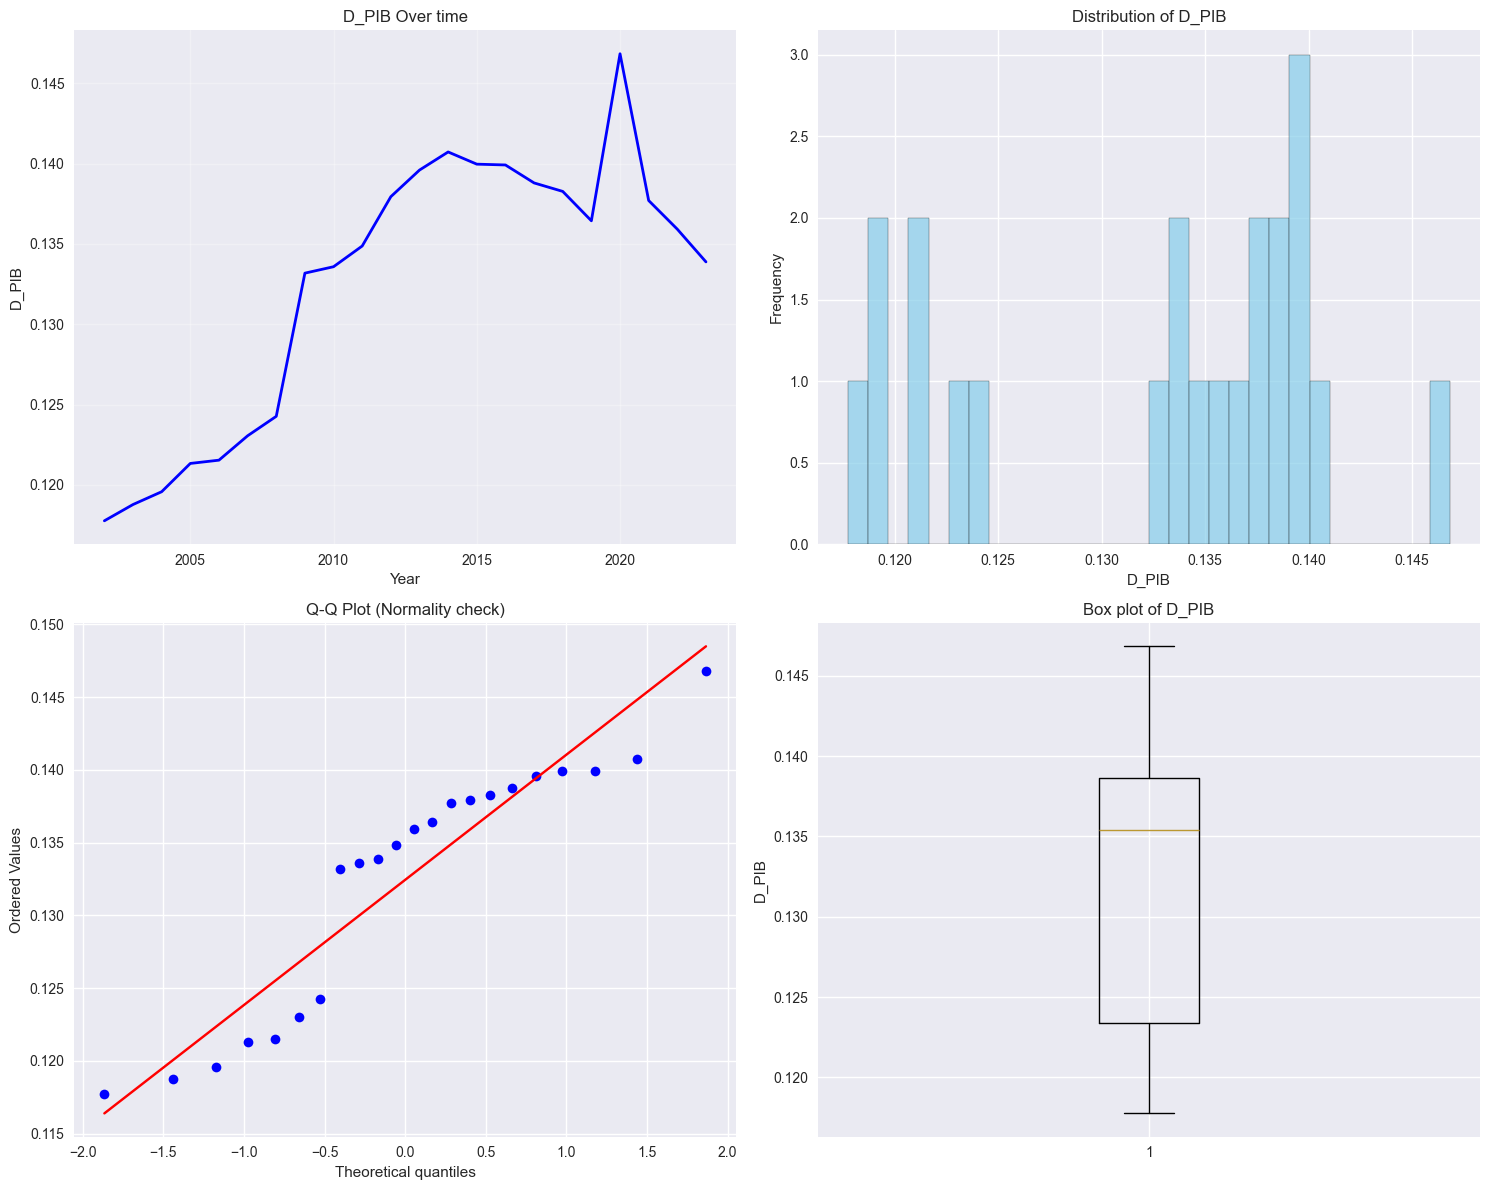

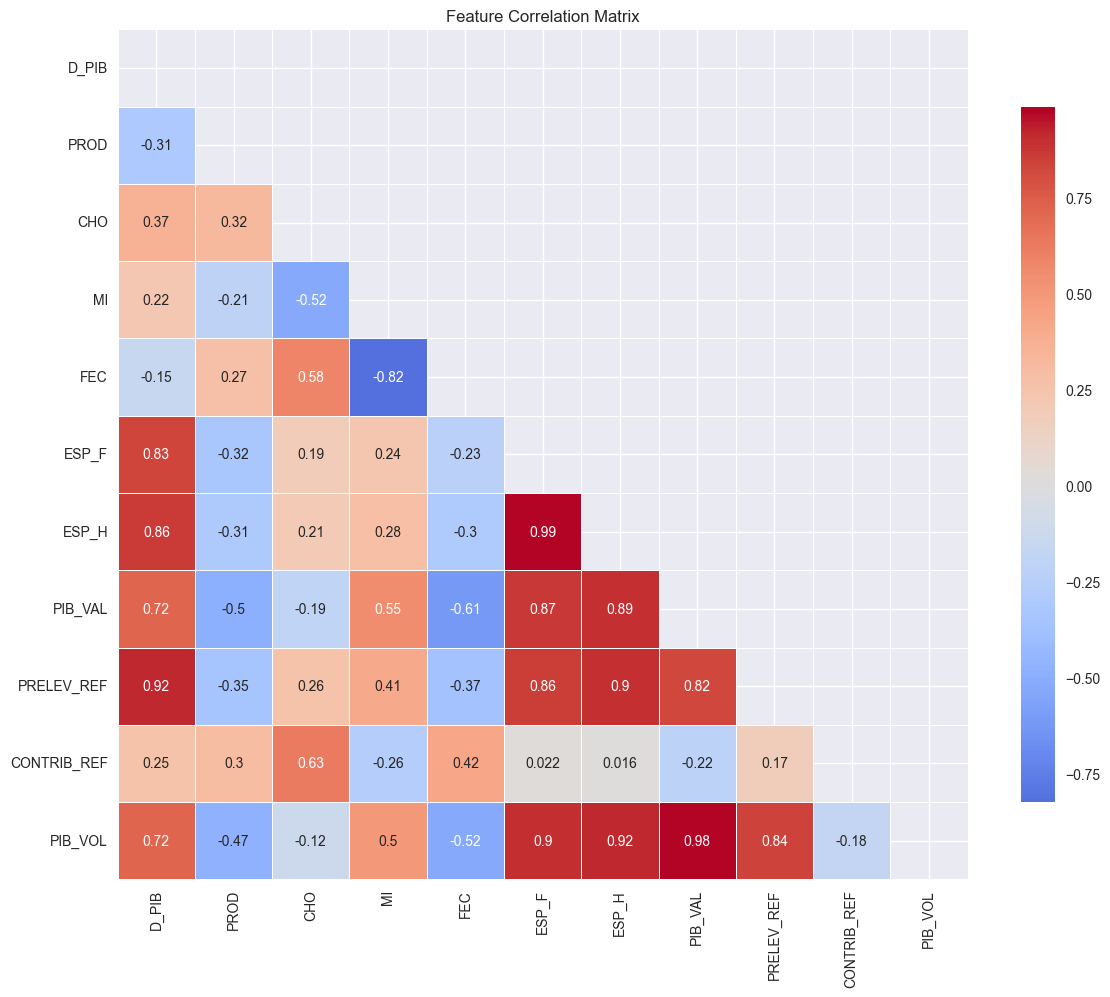

In [7]:
# Step 2: Visualize data
correlation_matrix = predictor.visualize_data()

In [8]:
correlation_matrix

,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
D_PIB,1.000000,-0.310382,0.368303,0.224880,-0.145707,0.830029,0.861941,0.722332,0.921060,0.252504,0.720773
PROD,-0.310382,1.000000,0.318183,-0.207562,0.265766,-0.321330,-0.306167,-0.495772,-0.348123,0.299241,-0.474188
CHO,0.368303,0.318183,1.000000,-0.522716,0.584635,0.191660,0.205829,-0.193953,0.258121,0.631753,-0.115912
MI,0.224880,-0.207562,-0.522716,1.000000,-0.821481,0.236710,0.284193,0.548707,0.407554,-0.264079,0.495579
FEC,-0.145707,0.265766,0.584635,-0.821481,1.000000,-0.229506,-0.299174,-0.612455,-0.368728,0.424874,-0.519222
ESP_F,0.830029,-0.321330,0.191660,0.236710,-0.229506,1.000000,0.985168,0.868557,0.857812,0.022379,0.904374
ESP_H,0.861941,-0.306167,0.205829,0.284193,-0.299174,0.985168,1.000000,0.889913,0.900351,0.016212,0.921387
PIB_VAL,0.722332,-0.495772,-0.193953,0.548707,-0.612455,0.868557,0.889913,1.000000,0.823197,-0.218540,0.979108
PRELEV_REF,0.921060,-0.348123,0.258121,0.407554,-0.368728,0.857812,0.900351,0.823197,1.000000,0.173132,0.842544
CONTRIB_REF,0.252504,0.299241,0.631753,-0.264079,0.424874,0.022379,0.016212,-0.218540,0.173132,1.000000,-0.177596


## Perform statistical stets on normality and stationarity

In [9]:
# Step 3: Statistical tests
predictor.statistical_tests()


Statistical tests and assumptions
Normality tests:
Jarque-Bera Test: statistic=1.9609, p-value=0.3751
Shapiro-Wilk Test: statistic=0.8836, p-value=0.0142
⚠ Data may not be normally distributed

Stationary tests:
Augmented Dickey-Fuller Test:
  ADF Statistic: -1.7959
  p-value: 0.3825
  Critical Values: {'1%': np.float64(-3.7883858816542486), '5%': np.float64(-3.013097747543462), '10%': np.float64(-2.6463967573696143)}
⚠ Series may be non-stationary (ADF test)


## Perform feature engineering (to be improved)

In [10]:
# Step 4: Feature engineering
X, y = predictor.feature_engineering()


Feature engineering and selection
Original features: 10
Feature names: ['PROD', 'CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF', 'CONTRIB_REF', 'PIB_VOL']

Creating lag features...
Features after engineering: 26
Samples after cleaning: 18
Selected features (15): ['CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF', 'PIB_VOL', 'CHO_lag1', 'CHO_lag2', 'ESP_F_lag1', 'ESP_F_lag2', 'PROD_roll5', 'CHO_roll3', 'CHO_roll5']


In [11]:
predictor.feature_names

Index(['CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF',
       'PIB_VOL', 'CHO_lag1', 'CHO_lag2', 'ESP_F_lag1', 'ESP_F_lag2',
       'PROD_roll5', 'CHO_roll3', 'CHO_roll5'],
      dtype='object')

In [12]:
# Step 5: Prepare data
X_scaled, y = predictor.prepare_data_for_modeling()


Data preparation and scaling
Applied RobustScaler to features
Set up TimeSeriesSplit with 5 folds


## Train different models

In [13]:
# Step 6: Train models
results = predictor.train_models()


Model training and comparison

Training Linear Regression...
  CV RMSE: 0.005637 (+/- 0.005499)

Training Ridge...
  Performing hyperparameter tuning...
  Best parameters: {'alpha': 0.1}
  CV RMSE: 0.004652 (+/- 0.005903)

Training Lasso...
  Performing hyperparameter tuning...
  Best parameters: {'alpha': 0.001}
  CV RMSE: 0.006764 (+/- 0.008411)

Training Elastic Net...
  CV RMSE: 0.007828 (+/- 0.006832)

Training Random Forest...
  Performing hyperparameter tuning...
  Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  CV RMSE: 0.006144 (+/- 0.007208)

Training Gradient Boosting...
  CV RMSE: 0.005860 (+/- 0.006565)

🏆 Champion model: Ridge
   CV RMSE: 0.004652


## Model evaluation


SModel evaluation and diagnostics
Final Model Performance (Ridge):
  RMSE: 0.000565
  MAE:  0.000501
  R²:   0.992115


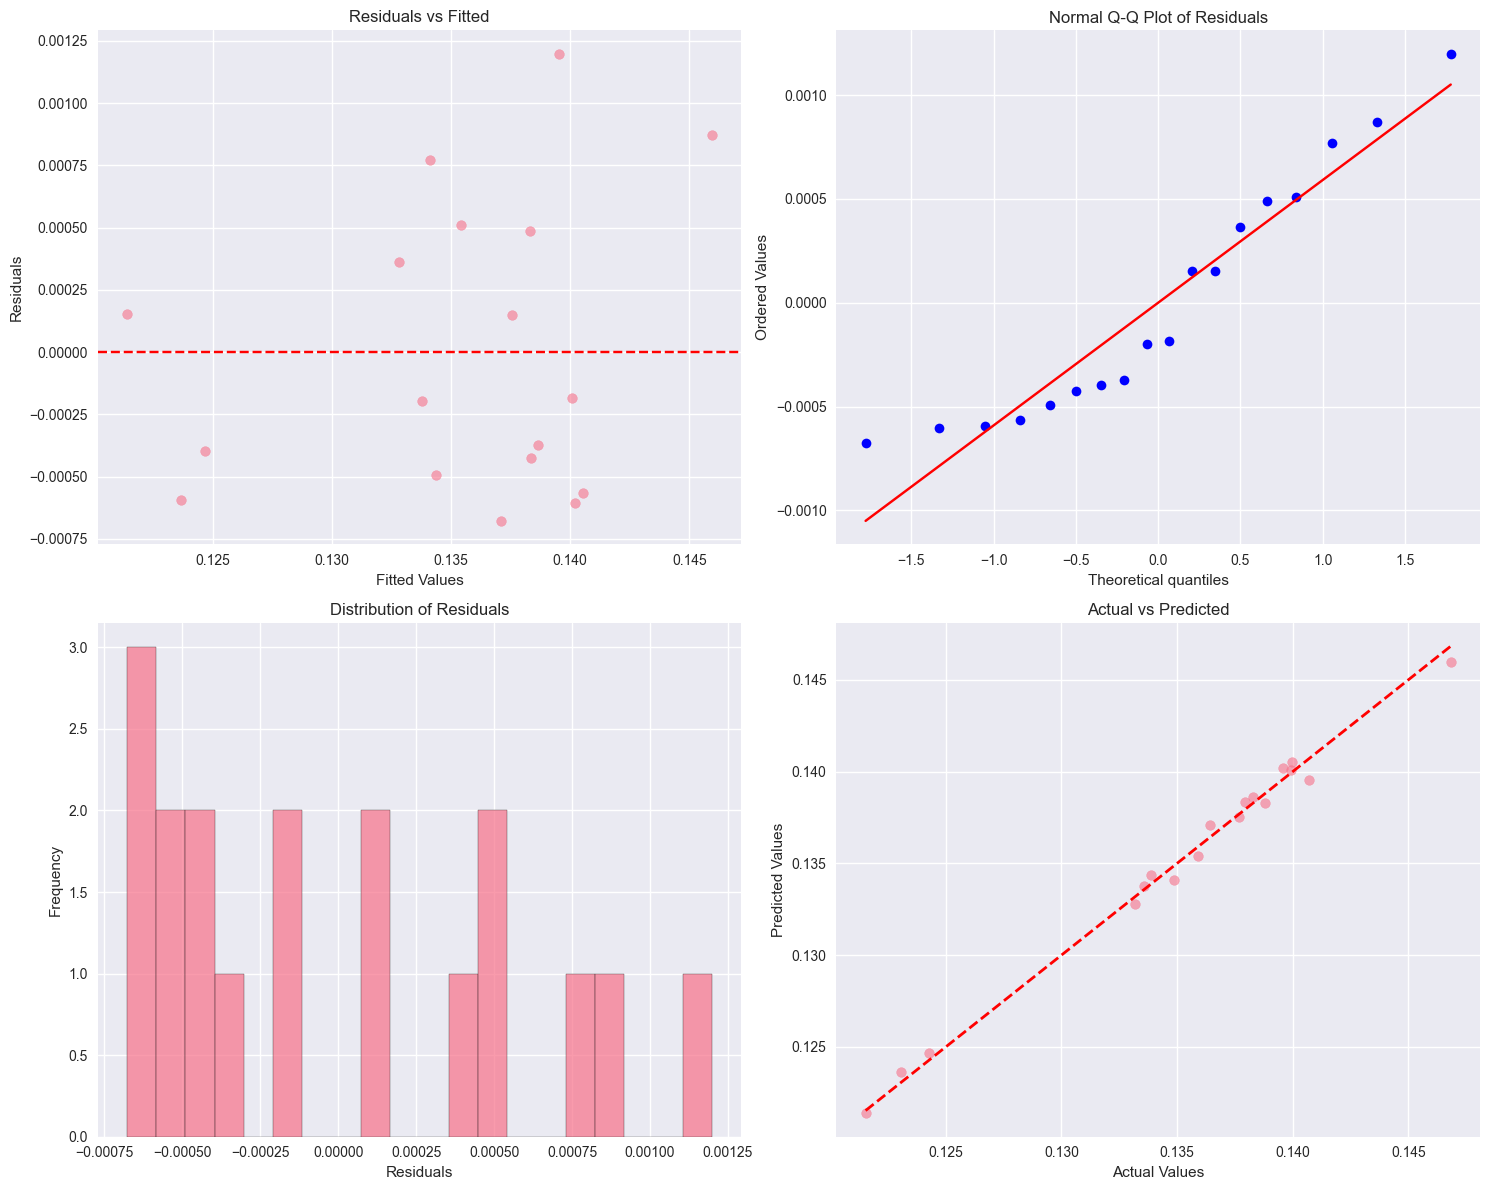

In [14]:
# Step 7: Evaluate best model
evaluation = predictor.evaluate_model()

In [15]:
evaluation

{'rmse': np.float64(0.0005654704406304997),
 'mae': 0.0005009066691796176,
 'r2': 0.9921150892372016,
 'residuals': 4     0.000154
 5    -0.000592
 6    -0.000398
 7     0.000363
 8    -0.000197
 9     0.000771
 10   -0.000427
 11   -0.000604
 12    0.001199
 13   -0.000564
 14   -0.000185
 15    0.000487
 16   -0.000371
 17   -0.000677
 18    0.000872
 19    0.000152
 20    0.000511
 21   -0.000493
 Name: D_PIB, dtype: float64,
 'predictions': array([0.1213818 , 0.12364412, 0.12466286, 0.13281343, 0.1337731 ,
        0.1340938 , 0.13836285, 0.14019589, 0.13951995, 0.1405235 ,
        0.14009488, 0.13830431, 0.13863464, 0.13711201, 0.14595929,
        0.13754518, 0.13540097, 0.1343694 ])}

In [16]:
evaluation['predictions']

array([0.1213818 , 0.12364412, 0.12466286, 0.13281343, 0.1337731 ,
       0.1340938 , 0.13836285, 0.14019589, 0.13951995, 0.1405235 ,
       0.14009488, 0.13830431, 0.13863464, 0.13711201, 0.14595929,
       0.13754518, 0.13540097, 0.1343694 ])

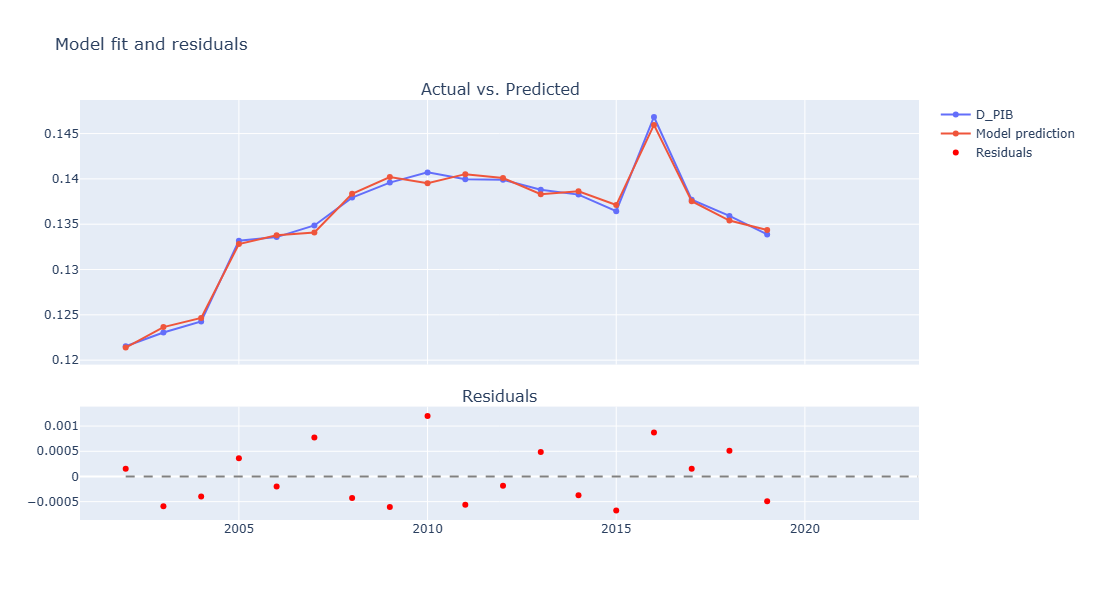

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = go.Figure()

# Create subplots: 2 rows, shared x-axis
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],  # Top plot 70%, bottom 30%
    vertical_spacing=0.1,
    subplot_titles=("Actual vs. Predicted", "Residuals")
)

# First scatter
fig.add_trace(go.Scatter(
    x=df['Annee'],
    y=predictor.y,
    mode='lines+markers',
    name='D_PIB'
), row=1, col=1)

# Add another scatter trace
fig.add_trace(go.Scatter(
    x=df['Annee'],
    y=evaluation['predictions'],
    mode='lines+markers',
    name='Model prediction'
), row=1, col=1)

# --- Bottom Plot: Residuals ---
fig.add_trace(go.Scatter(
    x=df['Annee'], 
    y=evaluation['residuals'],
    mode='markers',
    name='Residuals',
    marker=dict(color='red')
), row=2, col=1)

# Add a zero line for residuals
fig.add_shape(type="line", x0=df['Annee'].min(), x1=df['Annee'].max(),
              y0=0, y1=0, line=dict(dash='dash', color='gray'),
              row=2, col=1)

# Layout adjustments
fig.update_layout(height=600, title="Model fit and residuals", showlegend=True)

fig.show()

---
---

## Model comparison


Model comparison summary
Model performance ranking:
            Model  CV_RMSE_Mean  CV_RMSE_Std
            Ridge      0.004652     0.002951
Linear Regression      0.005637     0.002750
Gradient Boosting      0.005860     0.003282
    Random Forest      0.006144     0.003604
            Lasso      0.006764     0.004205
      Elastic Net      0.007828     0.003416


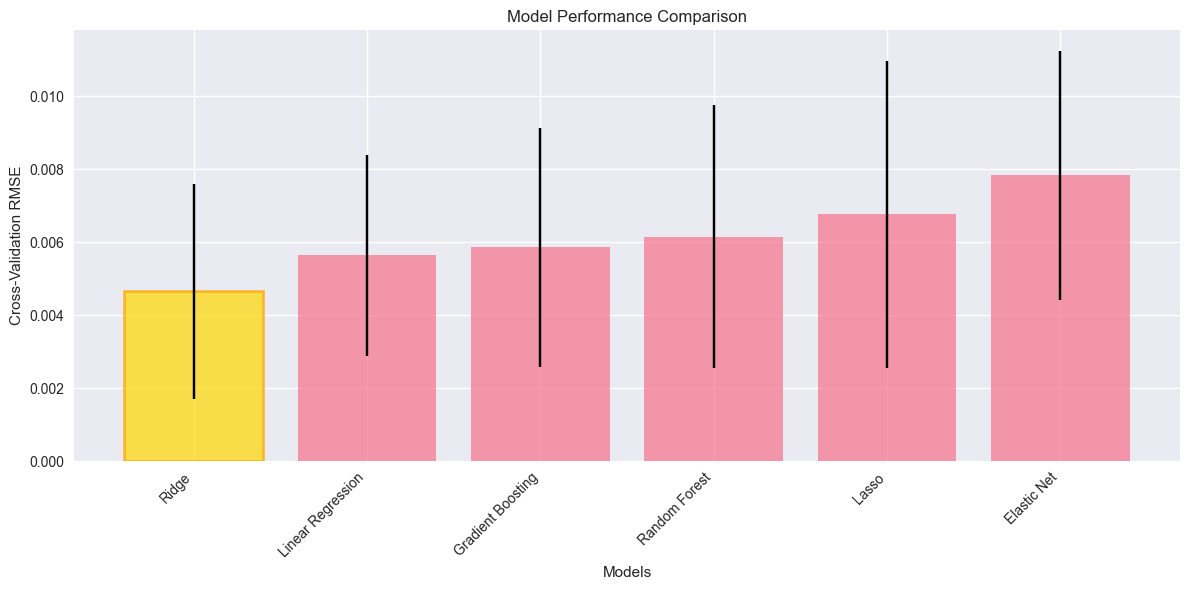

In [18]:
# Step 8: Model comparison
comparison = predictor.model_comparison_summary()

## Scenario prediction

In [19]:
# # Predict using a future scenario (df)
# predictor.predict_new_data(df)

---
---